In [1]:
import pandas as pd
import numpy as np

# Load cleaned datasets
df_afl = pd.read_csv("data/afl_marvel_clean.csv")
df_weather = pd.read_csv("data/melbourne_weather.csv")
df_holidays = pd.read_csv("data/public_holidays.csv")

# Convert dates
df_afl["date"] = pd.to_datetime(df_afl["date"])
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_holidays["date"] = pd.to_datetime(df_holidays["date"])

print("✅ All datasets loaded!")
print("AFL shape:", df_afl.shape)
print("Weather shape:", df_weather.shape)
print("Holidays shape:", df_holidays.shape)

✅ All datasets loaded!
AFL shape: (150, 8)
Weather shape: (1096, 4)
Holidays shape: (36, 2)


In [2]:
# Merge AFL games with weather data on date
df = pd.merge(df_afl, df_weather, on="date", how="left")

print("✅ Merged! Shape:", df.shape)
print(df.head())

✅ Merged! Shape: (150, 11)
   game_num       date round home_team home_score away_team   away_score  \
0   15986.0 2022-03-18    R1        St      Kilda  12.13.85  Collingwood   
1   15993.0 2022-03-24    R2   Western   Bulldogs  13.12.90      Carlton   
2   15996.0 2022-03-26    R2  Essendon   10.15.75  Brisbane        Lions   
3   16002.0 2022-03-31    R3   Western   Bulldogs   9.17.71       Sydney   
4   16009.0 2022-04-03    R3        St      Kilda  18.9.117     Richmond   

       venue  temperature_2m_max  precipitation_sum  windspeed_10m_max  
0  Docklands                21.5                1.6               22.7  
1  Docklands                20.4                0.0               18.4  
2  Docklands                23.7                0.0               12.4  
3  Docklands                20.9                0.2               28.4  
4  Docklands                17.8                0.8               13.8  


In [3]:
# Extract useful date features
df["day_of_week"] = df["date"].dt.dayofweek      # 0=Monday, 6=Sunday
df["day_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)  # 1 if Sat/Sun
df["is_friday_night"] = (df["day_of_week"] == 4).astype(int)  # 1 if Friday

print("✅ Date features added!")
print(df[["date", "day_name", "month", "is_weekend", "is_friday_night"]].head(10))

✅ Date features added!
        date  day_name  month  is_weekend  is_friday_night
0 2022-03-18    Friday      3           0                1
1 2022-03-24  Thursday      3           0                0
2 2022-03-26  Saturday      3           1                0
3 2022-03-31  Thursday      3           0                0
4 2022-04-03    Sunday      4           1                0
5 2022-04-09  Saturday      4           1                0
6 2022-04-10    Sunday      4           1                0
7 2022-04-17    Sunday      4           1                0
8 2022-04-30  Saturday      4           1                0
9 2022-05-01    Sunday      5           1                0


In [4]:
# Flag if game falls on or near a public holiday
holiday_dates = set(df_holidays["date"].dt.strftime("%Y-%m-%d"))

df["is_public_holiday"] = df["date"].dt.strftime("%Y-%m-%d").isin(holiday_dates).astype(int)

print("✅ Holiday feature added!")
print(f"Games on public holidays: {df['is_public_holiday'].sum()}")

✅ Holiday feature added!
Games on public holidays: 2


In [5]:
# Create simple weather flags
df["is_rainy"] = (df["precipitation_sum"] > 2).astype(int)   # more than 2mm = rainy
df["is_cold"] = (df["temperature_2m_max"] < 14).astype(int)  # under 14°C = cold

print("✅ Weather features added!")
print(f"Rainy games: {df['is_rainy'].sum()}")
print(f"Cold games: {df['is_cold'].sum()}")

✅ Weather features added!
Rainy games: 24
Cold games: 33


In [6]:
# Create target: is_high_traffic
# A game is "high traffic" if it's on a weekend OR friday night OR in finals months (Aug-Sept)
df["is_finals_month"] = df["month"].isin([8, 9]).astype(int)

df["is_high_traffic"] = (
    (df["is_weekend"] == 1) | 
    (df["is_friday_night"] == 1) | 
    (df["is_finals_month"] == 1)
).astype(int)

print("✅ Target variable created!")
print(df["is_high_traffic"].value_counts())
print(f"\nHigh traffic games: {df['is_high_traffic'].sum()} out of {len(df)}")

✅ Target variable created!
is_high_traffic
1    139
0     11
Name: count, dtype: int64

High traffic games: 139 out of 150


In [7]:
# Select only the columns the ML model will use
feature_cols = [
    "day_of_week",
    "month", 
    "is_weekend",
    "is_friday_night",
    "is_public_holiday",
    "is_rainy",
    "is_cold",
    "is_finals_month",
    "temperature_2m_max",
    "precipitation_sum",
    "windspeed_10m_max",
    "is_high_traffic"  # target variable
]

df_ml = df[feature_cols].copy()

print("✅ Final ML dataset shape:", df_ml.shape)
print("\nFeature summary:")
print(df_ml.describe())

# Save it
df_ml.to_csv("data/marvel_ml_ready.csv", index=False)
print("\n✅ Saved marvel_ml_ready.csv!")

✅ Final ML dataset shape: (150, 12)

Feature summary:
       day_of_week       month  is_weekend  is_friday_night  \
count   150.000000  150.000000  150.000000       150.000000   
mean      4.973333    5.693333    0.733333         0.193333   
std       0.897025    1.625909    0.443698         0.396235   
min       3.000000    3.000000    0.000000         0.000000   
25%       4.000000    4.000000    0.000000         0.000000   
50%       5.000000    5.000000    1.000000         0.000000   
75%       6.000000    7.000000    1.000000         0.000000   
max       6.000000    8.000000    1.000000         1.000000   

       is_public_holiday    is_rainy     is_cold  is_finals_month  \
count         150.000000  150.000000  150.000000       150.000000   
mean            0.013333    0.160000    0.220000         0.166667   
std             0.115082    0.367834    0.415634         0.373927   
min             0.000000    0.000000    0.000000         0.000000   
25%             0.000000    0.000

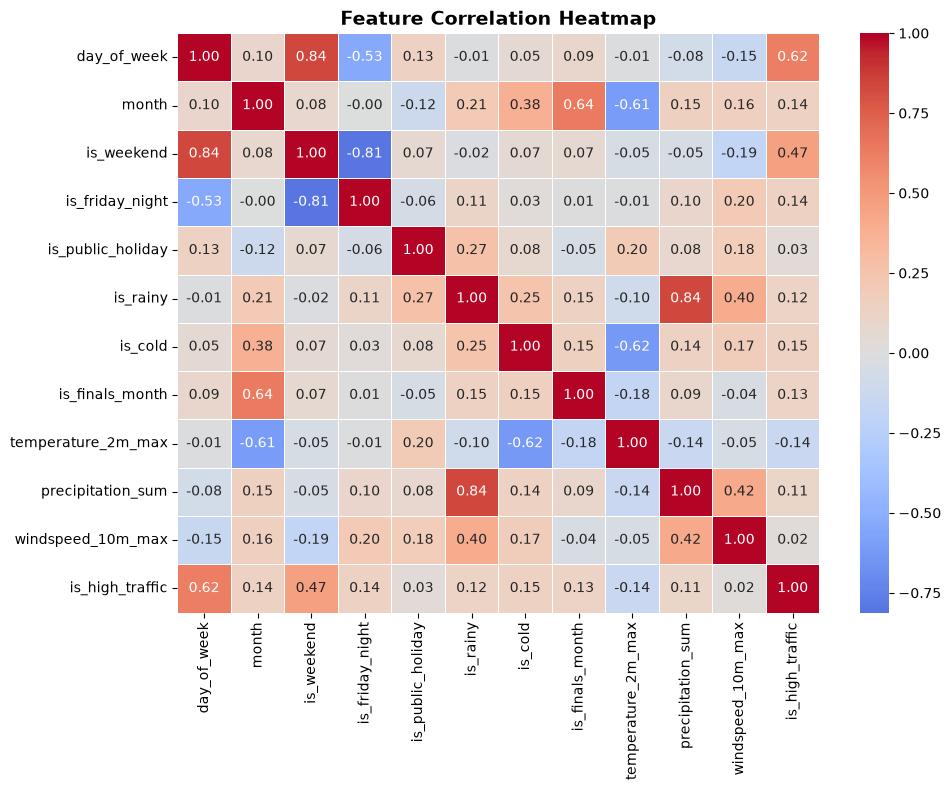

✅ Correlation heatmap saved!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df_ml.corr(), 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/chart5_correlations.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

In [9]:
# Check missing values
print("Missing values:")
print(df_ml.isnull().sum())

# Fill missing weather with median values (safe approach)
df_ml["temperature_2m_max"] = df_ml["temperature_2m_max"].fillna(df_ml["temperature_2m_max"].median())
df_ml["precipitation_sum"] = df_ml["precipitation_sum"].fillna(df_ml["precipitation_sum"].median())
df_ml["windspeed_10m_max"] = df_ml["windspeed_10m_max"].fillna(df_ml["windspeed_10m_max"].median())

# Verify no more missing values
print("\nAfter fixing:")
print(df_ml.isnull().sum())

# Save updated version
df_ml.to_csv("data/marvel_ml_ready.csv", index=False)
print("\n✅ Clean ML dataset saved — ready for modelling!")

Missing values:
day_of_week            0
month                  0
is_weekend             0
is_friday_night        0
is_public_holiday      0
is_rainy               0
is_cold                0
is_finals_month        0
temperature_2m_max    52
precipitation_sum     52
windspeed_10m_max     52
is_high_traffic        0
dtype: int64

After fixing:
day_of_week           0
month                 0
is_weekend            0
is_friday_night       0
is_public_holiday     0
is_rainy              0
is_cold               0
is_finals_month       0
temperature_2m_max    0
precipitation_sum     0
windspeed_10m_max     0
is_high_traffic       0
dtype: int64

✅ Clean ML dataset saved — ready for modelling!
